<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº2

#### Nicolás Galván

# Introducción

En este trabajo se estudia el proceso de digitalización de señales mediante un Convertidor Analógico-Digital (ADC), haciendo foco en los efectos de la cuantización y el muestreo sobre una señal senoidal. A partir de una extensión de la consigna previa, se incorpora al modelo la etapa de muestreo a una frecuencia definida, lo que permite analizar de manera más completa el comportamiento del sistema en un escenario más realista.

La señal de entrada considerada es una senoidal de energía normalizada, contaminada con ruido aditivo. Este ruido se modela como una secuencia incorrelada y de distribución gaussiana, cuya potencia se ajusta en función de la potencia del ruido de cuantización. De este modo, se puede controlar la relación entre ambos efectos y estudiar su impacto sobre la señal digitalizada.

El ADC simulado opera con un número finito de bits dentro de un rango analógico acotado, lo que introduce un error de cuantización característico. A partir de esta configuración, se analizan tanto las señales en el dominio temporal como sus representaciones espectrales, permitiendo observar fenómenos como la aparición de pisos de ruido y la degradación de la señal original.

Finalmente, se busca evaluar cómo influyen distintos parámetros del sistema, como la cantidad de bits del ADC y el nivel de ruido agregado, sobre la calidad de la señal digital obtenida. Este análisis permite comprender mejor los compromisos involucrados en el diseño y uso de sistemas de adquisición de datos.

## Ejercicio Nº1

### Item a

In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
N   = 1000
fs  = 1000
df  = fs / N
B   = 4
Vfs = 2
kn  = 1
f0 = df                 
A  = np.sqrt(2)         

In [22]:
qq = Vfs / (2**B)   


In [23]:
Pq = qq**2 / 12

In [24]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(0, nn) / fs
    velang = 2 * np.pi * ff
    xx = dc + vmax * np.sin(velang * tt + ph)
    return tt, xx

In [25]:
tt, ss = mi_funcion_sen(vmax=A, ff=f0, nn=N, fs=fs)

In [26]:
Pn  = kn * Pq
nn  = np.random.normal(0, np.sqrt(Pn), N)
sR  = ss + nn

In [27]:
sQ = np.round(sR / qq) * qq

eq = sQ - sR

In [28]:
piso_anal_dB = 10 * np.log10(Pn / (N/2))
piso_dig_dB  = 10 * np.log10(Pq / (N/2))

In [29]:
def espectro_uni_dB(x, N):
    X   = np.fft.fft(x) / N
    P   = np.abs(X)**2
    Pu  = P[:N//2 + 1].copy()
    Pu[1:-1] *= 2
    return 10 * np.log10(Pu + 1e-20)

In [30]:
frec = np.arange(N//2 + 1) * df

In [31]:
dB_sQ = espectro_uni_dB(sQ, N)
dB_ss = espectro_uni_dB(ss, N)
dB_sR = espectro_uni_dB(sR, N)

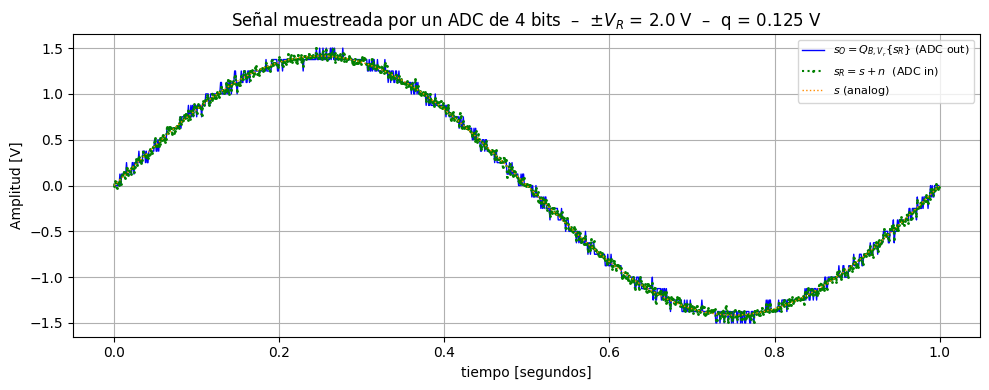

In [32]:
plt.figure(figsize=(10, 4))
plt.plot(tt, sQ,  color='blue',  lw=1,   label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(tt, sR,  'g.',  ms=2, ls='dotted',   label=r'$s_R = s + n$  (ADC in)')
plt.plot(tt, ss,  color='darkorange', lw=1, ls='dotted', label=r'$s$ (analog)')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

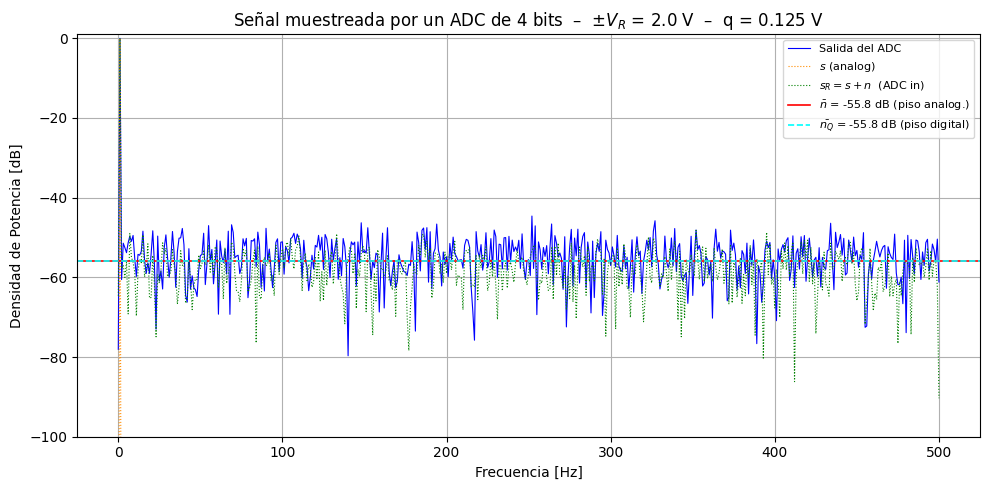

In [33]:
plt.figure(figsize=(10, 5))
plt.ylim(bottom=-100)
plt.plot(frec, dB_sQ, color='blue',  lw=0.8,            label=r'Salida del ADC')
plt.plot(frec, dB_ss, color='darkorange',  lw=0.8, ls='dotted', label=r'$s$ (analog)')
plt.plot(frec, dB_sR, color='green',      lw=0.8, ls='dotted', label=r'$s_R = s + n$  (ADC in)')

# Líneas horizontales de los pisos
plt.axhline(piso_anal_dB, color='red',  lw=1.2, ls='-', label=rf'$\bar{{n}}$ = {piso_anal_dB:.1f} dB (piso analog.)')
plt.axhline(piso_dig_dB,  color='cyan', lw=1.2, ls='--', label=rf'$\bar{{n_Q}}$ = {piso_dig_dB:.1f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

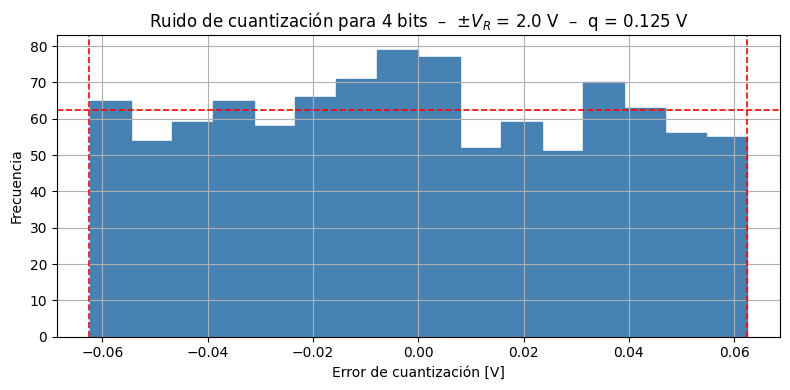

In [34]:
plt.figure(figsize=(8, 4))
plt.hist(eq, bins=16, color='steelblue', edgecolor='steelblue')

techo = N / 16          # misma altura que la línea teórica
x_izq = -qq / 2
x_der =  qq / 2

plt.axhline(techo, color='red', lw=1.2, ls='--')   # nivel uniforme teórico
plt.axvline(x_izq, color='red', lw=1.2, ls='--')    # pared izquierda
plt.axvline(x_der, color='red', lw=1.2, ls='--')    # pared derecha


plt.xlabel('Error de cuantización [V]')
plt.ylabel('Frecuencia')
plt.title(f'Ruido de cuantización para {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.grid(True)
plt.tight_layout()
plt.show()


### Item b

In [35]:
B   = 16
kn  = 10

In [36]:
qq = Vfs / (2**B)   

In [37]:
Pq = qq**2 / 12

In [38]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(0, nn) / fs
    velang = 2 * np.pi * ff
    xx = dc + vmax * np.sin(velang * tt + ph)
    return tt, xx

In [39]:
tt, ss = mi_funcion_sen(vmax=A, ff=f0, nn=N, fs=fs)

In [40]:
Pn  = kn * Pq
nn  = np.random.normal(0, np.sqrt(Pn), N)
sR  = ss + nn

In [41]:
sQ = np.round(sR / qq) * qq

eq = sQ - sR

In [42]:
piso_anal_dB = 10 * np.log10(Pn / (N/2))
piso_dig_dB  = 10 * np.log10(Pq / (N/2))

In [43]:
def espectro_uni_dB(x, N):
    X   = np.fft.fft(x) / N
    P   = np.abs(X)**2
    Pu  = P[:N//2 + 1].copy()
    Pu[1:-1] *= 2
    return 10 * np.log10(Pu + 1e-20)

In [44]:
frec = np.arange(N//2 + 1) * df

In [45]:
dB_sQ = espectro_uni_dB(sQ, N)
dB_ss = espectro_uni_dB(ss, N)
dB_sR = espectro_uni_dB(sR, N)

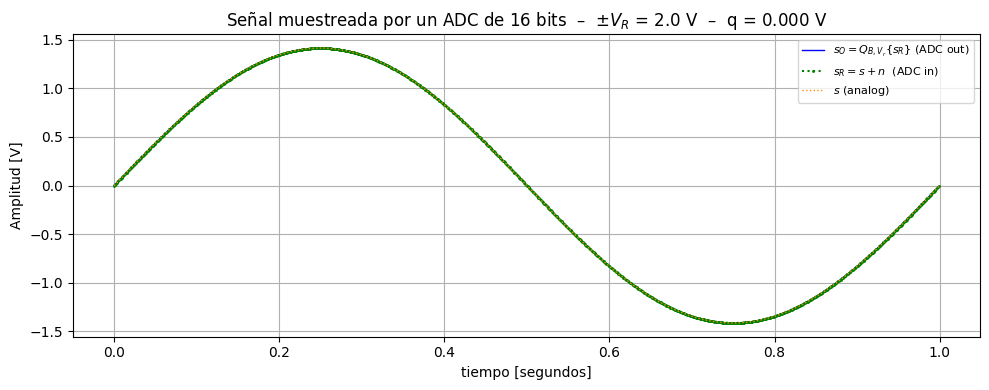

In [46]:
plt.figure(figsize=(10, 4))
plt.plot(tt, sQ,  color='blue',  lw=1,   label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(tt, sR,  'g.',  ms=2, ls='dotted',   label=r'$s_R = s + n$  (ADC in)')
plt.plot(tt, ss,  color='darkorange', lw=1, ls='dotted', label=r'$s$ (analog)')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

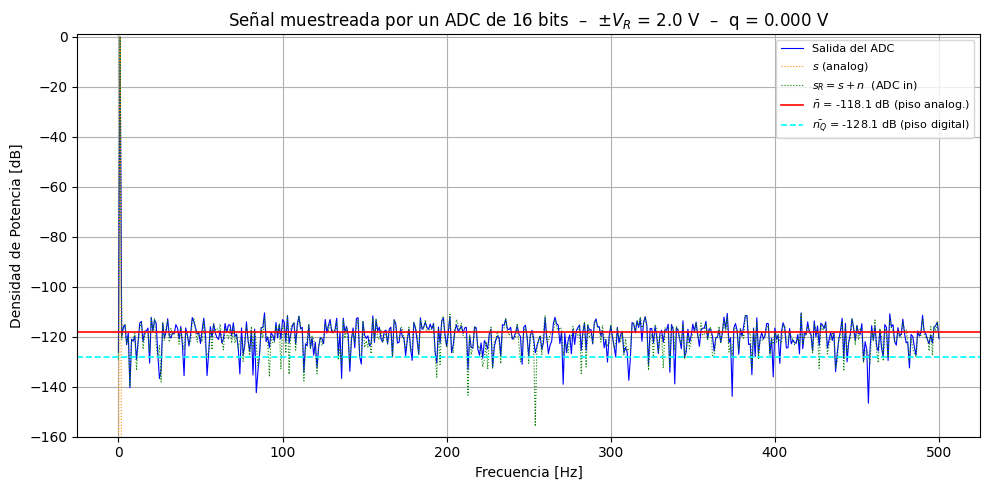

In [50]:
plt.figure(figsize=(10, 5))
plt.ylim(bottom=-160)
plt.plot(frec, dB_sQ, color='blue',  lw=0.8,            label=r'Salida del ADC')
plt.plot(frec, dB_ss, color='darkorange',  lw=0.8, ls='dotted', label=r'$s$ (analog)')
plt.plot(frec, dB_sR, color='green',      lw=0.8, ls='dotted', label=r'$s_R = s + n$  (ADC in)')

# Líneas horizontales de los pisos
plt.axhline(piso_anal_dB, color='red',  lw=1.2, ls='-', label=rf'$\bar{{n}}$ = {piso_anal_dB:.1f} dB (piso analog.)')
plt.axhline(piso_dig_dB,  color='cyan', lw=1.2, ls='--', label=rf'$\bar{{n_Q}}$ = {piso_dig_dB:.1f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

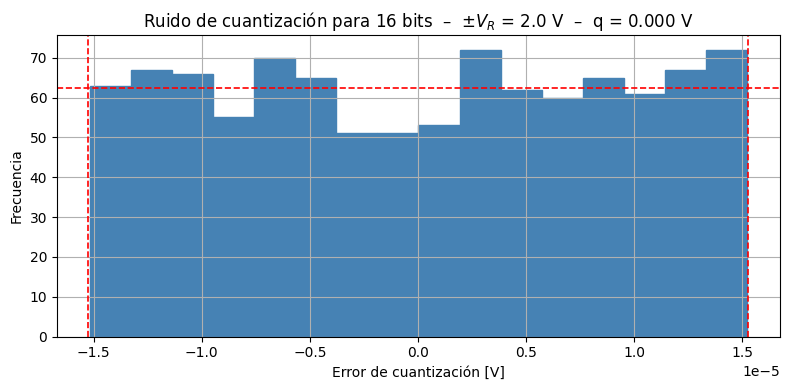

In [48]:
plt.figure(figsize=(8, 4))
plt.hist(eq, bins=16, color='steelblue', edgecolor='steelblue')

techo = N / 16          # misma altura que la línea teórica
x_izq = -qq / 2
x_der =  qq / 2

plt.axhline(techo, color='red', lw=1.2, ls='--')   # nivel uniforme teórico
plt.axvline(x_izq, color='red', lw=1.2, ls='--')    # pared izquierda
plt.axvline(x_der, color='red', lw=1.2, ls='--')    # pared derecha


plt.xlabel('Error de cuantización [V]')
plt.ylabel('Frecuencia')
plt.title(f'Ruido de cuantización para {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.grid(True)
plt.tight_layout()
plt.show()

# Análisis de Resultados

Se comparan los resultados obtenidos para dos configuraciones del sistema: por un lado, \(B = 4\) bits y \(k_n = 1\), y por otro, \(B = 16\) bits y \(k_n = 10\).

Para el caso de \(B = 4\) y \(k_n = 1\), la señal de salida del ADC presenta una degradación moderada. Esto se debe a que el ruido de cuantización es significativo (debido a la baja resolución) y, al mismo tiempo, el ruido analógico tiene una potencia comparable. En el dominio temporal se observa una señal escalonada con dispersión alrededor de la senoidal ideal, evidenciando la presencia simultánea de ambos efectos.

En contraste, para la configuración \(B = 16\) bits y \(k_n = 10\), la situación cambia notablemente. El aumento en la cantidad de bits reduce considerablemente el paso de cuantización, haciendo que el error de cuantización sea prácticamente despreciable. Como resultado, la señal cuantizada (\(s_Q\)) sigue muy de cerca a la señal de entrada (\(s_R\)), sin presentar escalonamientos visibles.

Sin embargo, al incrementarse el factor \(k_n\), la potencia del ruido analógico se vuelve dominante. Esto implica que, aunque el ADC tenga una alta resolución, la calidad final de la señal está limitada principalmente por el ruido presente en la entrada. En otras palabras, la mejora en la cuantización no se traduce en una mejora proporcional en la señal final, ya que el ruido analógico enmascara cualquier beneficio adicional.

Comparando ambas configuraciones, se observa que:
- En el primer caso (\(B = 4\), \(k_n = 1\)), la limitación está dada tanto por la cuantización como por el ruido.
- En el segundo caso (\(B = 16\), \(k_n = 10\)), la limitación está dominada por el ruido analógico.

Respecto a lo obtenido en el apartado anterior, estos resultados evidencian el compromiso fundamental en sistemas de adquisición: aumentar la resolución del ADC solo es útil si el nivel de ruido analógico es suficientemente bajo. De lo contrario, el sistema queda limitado por el ruido de entrada y no por la cuantización.

En conclusión, el análisis conjunto muestra que no siempre incrementar la cantidad de bits mejora el desempeño global, sino que es necesario considerar simultáneamente el nivel de ruido presente en la señal para optimizar el sistema.

### Autoevaluación del aprendisaje

A lo largo de este trabajo práctico se logró profundizar en la comprensión del proceso de digitalización de señales mediante un ADC, incorporando no solo el efecto de la cuantización sino también el impacto del muestreo y del ruido analógico aditivo. En relación con los objetivos planteados en la introducción, se pudo verificar cómo una señal senoidal de energía normalizada se ve afectada por estos fenómenos, tanto en el dominio temporal como en el espectral.

En una primera instancia (apartado a), se implementó el modelo completo del ADC con una configuración de referencia (B = 4 bits y \(k_n = 1\)). Esto permitió observar claramente la presencia del ruido de cuantización, la discretización en amplitud de la señal y la aparición de pisos de ruido bien definidos en el espectro. Asimismo, el histograma del error de cuantización evidenció una distribución aproximadamente uniforme, en concordancia con el modelo teórico.

En una segunda etapa, se analizó el comportamiento del sistema al modificar los parámetros del ADC y del ruido analógico, considerando distintas configuraciones de resolución y niveles de ruido, en nuestro caso B = 16 bits y k_n = 10. Este análisis permitió extraer las siguientes conclusiones:

- Al aumentar la cantidad de bits, disminuye el paso de cuantización, reduciendo así la potencia del ruido de cuantización. Esto se traduce en una mejora significativa en la calidad de la señal digital y en una disminución del piso de ruido digital en el espectro.
- Para valores bajos de \(k_n\), el ruido analógico es despreciable frente al de cuantización, por lo que el desempeño del sistema está limitado principalmente por la resolución del ADC.
- Para valores altos de \(k_n\), el ruido analógico domina, elevando el piso de ruido total y enmascarando los beneficios de aumentar la cantidad de bits.
- Existe un compromiso entre resolución y nivel de ruido: incrementar \(B\) más allá de cierto punto no produce mejoras apreciables si el ruido analógico es elevado.

En comparación con los resultados obtenidos en el apartado a), se pudo observar que dicha configuración representa un caso intermedio donde ambos tipos de ruido tienen contribuciones similares. Esto permitió utilizarla como referencia para evaluar cómo varía el sistema al modificar cada parámetro de manera independiente.

En conclusión, este trabajo permitió no solo implementar un modelo funcional de un ADC, sino también interpretar sus limitaciones prácticas y comprender la relación entre cuantización, ruido y calidad de señal, aspectos fundamentales en sistemas de adquisición y procesamiento digital.